In [1]:
import statsmodels.api as sm
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

#%matplotlib ipympl

In [2]:
# 학습 데이터 생성
bias = 100
X0, y, w = make_regression(
    n_samples=100, n_features=2, bias=bias,
    noise=10, coef=True, random_state=1)
X = sm.add_constant(X0)
print("이론적 관계:")
print("y = %.2f + %.2f*x1 + %.2f*x2" % (bias, w[0], w[1]))

이론적 관계:
y = 100.00 + 32.27*x1 + 86.45*x2


In [3]:
# statsmodel의 OLS
model = sm.OLS(y, X)
result = model.fit()

print("추정한 관계:")
print("y = %.2f + %.2f*x1 + %.2f*x2" % (result.params[0], result.params[1], result.params[2]))

추정한 관계:
y = 100.73 + 31.31*x1 + 83.68*x2


In [4]:
# 분석 결과 출력
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     2620.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.84e-85
Time:                        08:08:44   Log-Likelihood:                -372.50
No. Observations:                 100   AIC:                             751.0
Df Residuals:                      97   BIC:                             758.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.7304      1.054     95.564      0.0

In [5]:
# 신규 데이터에 대한 예측
X_new = [[0.012345, -0.104532], [-0.16539, 0.15843]]
X_new = sm.add_constant(X_new)
yhat = result.predict(X_new)
print("{0}에 대한 예측치: {1}".format(X_new, yhat))

[[ 1.        0.012345 -0.104532]
 [ 1.       -0.16539   0.15843 ]]에 대한 예측치: [ 92.36983533 108.80932525]


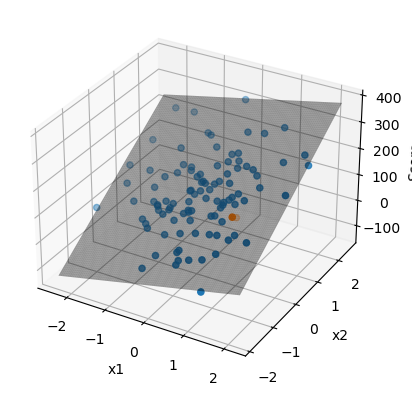

In [6]:
# 그래프 출력
X1_new = np.linspace(np.min(X0[:,0]), np.max(X0[:,0]), 100)
X2_new = np.linspace(np.min(X0[:,1]), np.max(X0[:,1]), 100)
m, n = np.meshgrid(X1_new, X2_new)

ax = plt.axes(projection='3d')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Score')
ax.scatter(X0[:,0], X0[:,1], y)

x1 = [i[0] for i in X_new]
x2 = [i[1] for i in X_new]
ax.scatter(x1, x2, yhat)

z = m*result.params[1] + n*result.params[2] + result.params[0]
ax.plot_surface(m, n, z, rstride=1, cstride=1, color='none', alpha=0.4)
plt.show()

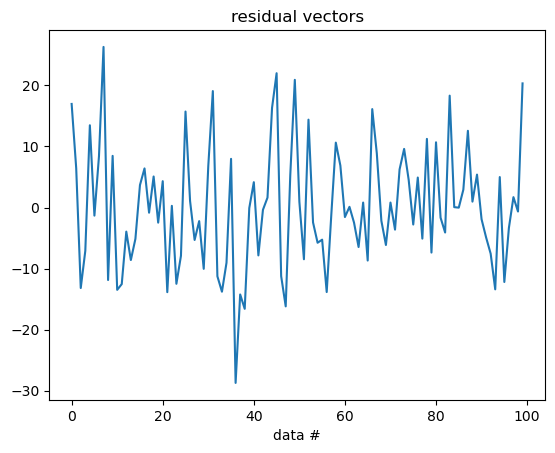

In [7]:
# 그래프 출력
X = np.arange(X0.shape[0])
plt.plot(X, result.resid)
plt.title("residual vectors")
plt.xlabel("data #")
plt.show()